In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        pass

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

job_id                                                                 1
title                                                   Marketing Intern
location                                                US, NY, New York
department                                                     Marketing
salary_range                                                         NaN
company_profile        We're Food52, and we've created a groundbreaki...
description            Food52, a fast-growing, James Beard Award-winn...
requirements           Experience with content management systems a m...
benefits                                                             NaN
telecommuting                                                          0
has_company_logo                                                       1
has_questions                                                          0
employment_type                                                    Other
required_experience                                

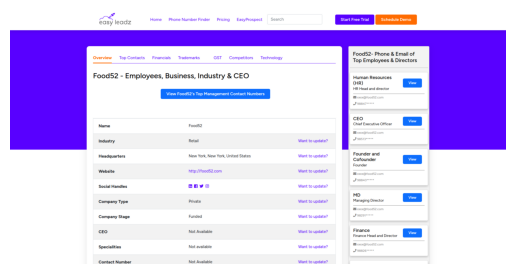

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv("/kaggle/input/multimodal-real-fake-job-posting-prediction/fake_job_postings.csv")
base_path = "/kaggle/input/multimodal-real-fake-job-posting-prediction/images"
df['webpage_screenshot'] = df.apply(lambda x: f"{base_path}/{x['fraudulent']}/{x['job_id']}.png", axis=1)

print(df.loc[0])

first_image_path = df.loc[0, 'webpage_screenshot']
if os.path.exists(first_image_path):
    img = plt.imread(first_image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print(f"Image not found: {first_image_path}")


In [3]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from transformers import BertTokenizer, BertModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

class EarlyStopping:
    def __init__(self, patience=7, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_f1 = 0

    def __call__(self, val_loss, f1_score):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_f1 = f1_score
        elif val_loss > self.best_loss - self.delta and f1_score <= self.best_f1:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_f1 = f1_score
            self.counter = 0
        return self.early_stop

df = pd.read_csv("/kaggle/input/multimodal-real-fake-job-posting-prediction/fake_job_postings.csv")
base_path = "/kaggle/input/multimodal-real-fake-job-posting-prediction/images"
df['webpage_screenshot'] = df.apply(lambda x: f"{base_path}/{x['fraudulent']}/{x['job_id']}.png", axis=1)

text_features = ['title', 'location', 'department', 'company_profile', 'description', 'requirements', 'benefits']
df['text'] = df[text_features].fillna("").agg(" ".join, axis=1)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class_weights = compute_class_weight('balanced', classes=np.unique(df['fraudulent']), y=df['fraudulent'])
class_weight_tensor = torch.FloatTensor(class_weights)

tfidf_vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
bow_vectorizer = CountVectorizer(max_features=500, binary=True)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['fraudulent'], random_state=42)

tfidf_features_train = tfidf_vectorizer.fit_transform(train_df['text']).toarray()
tfidf_features_test = tfidf_vectorizer.transform(test_df['text']).toarray()

bow_features_train = bow_vectorizer.fit_transform(train_df['text']).toarray()
bow_features_test = bow_vectorizer.transform(test_df['text']).toarray()

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

class JobDataset(Dataset):
    def __init__(self, df, tokenizer, tfidf_features, bow_features, max_len=256, augment=False):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.tfidf_features = tfidf_features
        self.bow_features = bow_features
        self.augment = augment
        
        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.RandomHorizontalFlip(p=0.3),
                transforms.RandomRotation(10),
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(row['text'], truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")
        img_path = row['webpage_screenshot']
        try:
            img = Image.open(img_path).convert("RGB")
        except:
            img = Image.new("RGB", (224, 224), color=(128, 128, 128))
        img = self.transform(img)
        
        tfidf_feat = torch.FloatTensor(self.tfidf_features[idx])
        bow_feat = torch.FloatTensor(self.bow_features[idx])
        
        return (
            enc["input_ids"].squeeze(0), 
            enc["attention_mask"].squeeze(0), 
            img, 
            tfidf_feat,
            bow_feat,
            torch.tensor(row['fraudulent'], dtype=torch.long)
        )

train_dataset = JobDataset(train_df, tokenizer, tfidf_features_train, bow_features_train, augment=True)
test_dataset = JobDataset(test_df, tokenizer, tfidf_features_test, bow_features_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

class MultiKernelBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        mid = out_ch // 3
        self.b3 = nn.Conv2d(in_ch, mid, kernel_size=3, padding=1, bias=False)
        self.b5 = nn.Conv2d(in_ch, mid, kernel_size=5, padding=2, bias=False)
        self.b7 = nn.Conv2d(in_ch, out_ch - 2 * mid, kernel_size=7, padding=3, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        if in_ch != out_ch:
            self.short = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        else:
            self.short = nn.Identity()

    def forward(self, x):
        o1 = self.b3(x)
        o2 = self.b5(x)
        o3 = self.b7(x)
        out = torch.cat([o1, o2, o3], dim=1)
        out = self.bn(out)
        sc = self.short(x)
        return self.relu(out + sc)

class MultiKernelResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )
        self.l1 = nn.Sequential(MultiKernelBlock(64, 128), nn.MaxPool2d(2))
        self.l2 = nn.Sequential(MultiKernelBlock(128, 256), nn.MaxPool2d(2))
        self.l3 = nn.Sequential(MultiKernelBlock(256, 512), nn.MaxPool2d(2))
        self.l4 = MultiKernelBlock(512, 512)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.out_dim = 512

    def forward(self, x):
        x = self.stem(x)
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        x = self.l4(x)
        x = self.pool(x)
        return torch.flatten(x, 1)

bert = BertModel.from_pretrained("bert-base-uncased")
for p in bert.parameters():
    p.requires_grad = False

resnet = MultiKernelResNet()

class MultiModalClassifier(nn.Module):
    def __init__(self, bert, resnet, tfidf_dim=1000, bow_dim=500, dropout_rate=0.4):
        super().__init__()
        self.bert = bert
        self.resnet = resnet
        
        self.tfidf_fc = nn.Sequential(
            nn.Linear(tfidf_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate)
        )
        
        self.bow_fc = nn.Sequential(
            nn.Linear(bow_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        self.bert_fc = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate)
        )
        
        self.img_fc = nn.Sequential(
            nn.Linear(resnet.out_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate)
        )
        
        self.fusion_fc = nn.Sequential(
            nn.Linear(896, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 2)
        )
        
        self.tfidf_classifier = nn.Linear(256, 2)
        self.bow_classifier = nn.Linear(128, 2)
        self.bert_classifier = nn.Linear(256, 2)
        self.img_classifier = nn.Linear(256, 2)
        
        self.alpha = nn.Parameter(torch.tensor(1.0))
        self.beta = nn.Parameter(torch.tensor(1.0))
        self.gamma = nn.Parameter(torch.tensor(1.0))
        self.delta = nn.Parameter(torch.tensor(1.0))

    def forward(self, input_ids, mask, images, tfidf_feats, bow_feats):
        with torch.no_grad():
            bert_output = self.bert(input_ids=input_ids, attention_mask=mask).pooler_output
        
        img_feat = self.resnet(images)
        
        tfidf_p = self.tfidf_fc(tfidf_feats)
        bow_p = self.bow_fc(bow_feats)
        bert_p = self.bert_fc(bert_output)
        img_p = self.img_fc(img_feat)
        
        tfidf_logits = self.tfidf_classifier(tfidf_p)
        bow_logits = self.bow_classifier(bow_p)
        bert_logits = self.bert_classifier(bert_p)
        img_logits = self.img_classifier(img_p)
        
        combined = torch.cat([tfidf_p, bow_p, bert_p, img_p], dim=1)
        fusion_logits = self.fusion_fc(combined)
        
        return fusion_logits, tfidf_logits, bow_logits, bert_logits, img_logits

class AdaptiveMultiTaskLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.crit = nn.CrossEntropyLoss(weight=class_weights)
        
    def forward(self, model, fusion_logits, tfidf_logits, bow_logits, bert_logits, img_logits, labels):
        f_l = self.crit(fusion_logits, labels)
        t_l = self.crit(tfidf_logits, labels)
        b_l = self.crit(bow_logits, labels)
        bt_l = self.crit(bert_logits, labels)
        i_l = self.crit(img_logits, labels)
        
        a = torch.exp(model.alpha)
        b = torch.exp(model.beta)
        g = torch.exp(model.gamma)
        d = torch.exp(model.delta)
        
        s = a + b + g + d
        an = a / s
        bn = b / s
        gn = g / s
        dn = d / s
        
        total = f_l + an * t_l + bn * b_l + gn * bt_l + dn * i_l
        
        return total, f_l, t_l, b_l, bt_l, i_l, an, bn, gn, dn

device = "cuda" if torch.cuda.is_available() else "cpu"
model = MultiModalClassifier(bert, resnet).to(device)

optimizer = torch.optim.AdamW([
    {'params': model.tfidf_fc.parameters(), 'lr': 3e-4},
    {'params': model.bow_fc.parameters(), 'lr': 3e-4},
    {'params': model.bert_fc.parameters(), 'lr': 1e-4},
    {'params': model.img_fc.parameters(), 'lr': 1e-4},
    {'params': model.resnet.parameters(), 'lr': 1e-5},
    {'params': model.fusion_fc.parameters(), 'lr': 2e-4},
    {'params': model.tfidf_classifier.parameters(), 'lr': 3e-4},
    {'params': model.bow_classifier.parameters(), 'lr': 3e-4},
    {'params': model.bert_classifier.parameters(), 'lr': 2e-4},
    {'params': model.img_classifier.parameters(), 'lr': 2e-4},
    {'params': [model.alpha, model.beta, model.gamma, model.delta], 'lr': 1e-3}
], weight_decay=0.01)

criterion = AdaptiveMultiTaskLoss(class_weights=class_weight_tensor.to(device))
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7)

best_f1 = 0
max_epochs = 50

for epoch in range(max_epochs):
    model.train()
    train_loss = 0
    
    for ids, mask, imgs, tfidf_feats, bow_feats, labels in train_loader:
        ids = ids.to(device)
        mask = mask.to(device)
        imgs = imgs.to(device)
        tfidf_feats = tfidf_feats.to(device)
        bow_feats = bow_feats.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        fusion_logits, tfidf_logits, bow_logits, bert_logits, img_logits = model(ids, mask, imgs, tfidf_feats, bow_feats)
        loss, _, _, _, _, _, a, b, g, d = criterion(model, fusion_logits, tfidf_logits, bow_logits, bert_logits, img_logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    y_true, y_pred, y_prob = [], [], []
    val_loss = 0
    
    with torch.no_grad():
        for ids, mask, imgs, tfidf_feats, bow_feats, labels in test_loader:
            ids = ids.to(device)
            mask = mask.to(device)
            imgs = imgs.to(device)
            tfidf_feats = tfidf_feats.to(device)
            bow_feats = bow_feats.to(device)
            
            fusion_logits, tfidf_logits, bow_logits, bert_logits, img_logits = model(ids, mask, imgs, tfidf_feats, bow_feats)
            loss, _, _, _, _, _, a, b, g, d = criterion(model, fusion_logits, tfidf_logits, bow_logits, bert_logits, img_logits, labels.to(device))
            val_loss += loss.item()
            
            probs = torch.softmax(fusion_logits, dim=1)
            preds = torch.argmax(fusion_logits, 1).cpu().numpy()
            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_prob.extend(probs[:, 1].cpu().numpy())

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(test_loader)
    
    f1 = f1_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    
    scheduler.step(avg_val)
    
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"Epoch {epoch+1}: Train Loss {avg_train:.4f}, Val Loss {avg_val:.4f}, Acc {acc:.4f}, F1 {f1:.4f}")
    print(f"Weights α {a.item():.3f}, β {b.item():.3f}, γ {g.item():.3f}, δ {d.item():.3f}")

    if early_stopping(avg_val, f1):
        print(f"Stop at {epoch+1}")
        break

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for ids, mask, imgs, tfidf_feats, bow_feats, labels in test_loader:
        ids = ids.to(device)
        mask = mask.to(device)
        imgs = imgs.to(device)
        tfidf_feats = tfidf_feats.to(device)
        bow_feats = bow_feats.to(device)
        
        fusion_logits, _, _, _, _ = model(ids, mask, imgs, tfidf_feats, bow_feats)
        probs = torch.softmax(fusion_logits, dim=1)
        preds = torch.argmax(fusion_logits, 1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs[:, 1].cpu().numpy())

print("\nFinal Results")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1: {f1_score(y_true, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
print("\nReport:")
print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))


2025-11-24 02:52:22.068850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763952742.505549      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763952742.633180      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch 1: Train Loss 1.0358, Val Loss 0.7617, Acc 0.9628, F1 0.6211
Weights α 0.535, β 0.223, γ 0.123, δ 0.120
Epoch 2: Train Loss 0.7376, Val Loss 0.8954, Acc 0.9815, F1 0.7770
Weights α 0.793, β 0.128, γ 0.039, δ 0.039
Epoch 3: Train Loss 0.6971, Val Loss 0.9570, Acc 0.9824, F1 0.7879
Weights α 0.910, β 0.057, γ 0.016, δ 0.016
Epoch 4: Train Loss 0.5430, Val Loss 0.9616, Acc 0.9720, F1 0.7207
Weights α 0.955, β 0.029, γ 0.008, δ 0.008
Epoch 5: Train Loss 0.4161, Val Loss 1.0013, Acc 0.9846, F1 0.8220
Weights α 0.974, β 0.017, γ 0.004, δ 0.004
Epoch 6: Train Loss 0.2827, Val Loss 0.8387, Acc 0.9841, F1 0.8246
Weights α 0.981, β 0.012, γ 0.003, δ 0.003
Epoch 7: Train Loss 0.1834, Val Loss 1.0017, Acc 0.9849, F1 0.8313
Weights α 0.986, β 0.009, γ 0.002, δ 0.002
Epoch 8: Train Loss 0.1166, Val Loss 1.2117, Acc 0.9824, F1 0.8037
Weights α 0.990, β 0.007, γ 0.002, δ 0.002
Epoch 9: Train Loss 0.0936, Val Loss 1.2482, Acc 0.9846, F1 0.8254
Weights α 0.993, β 0.005, γ 0.001, δ 0.001
Epoch 10: 